In [1]:
# Full Inference Pipeline - Production Test
# Uses production models (set before any imports)
import os
import sys
import random
from pathlib import Path

os.environ['USE_PRODUCTION_MODELS'] = 'true'
sys.path.insert(0, str(Path().resolve().parent))

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Calibration
from src.inference import (
    load_all_models,
    run_end_to_end_inference_simple,
    load_all_ground_truth,
)
from src.visualization import (
    show_gt_vs_pred,
    gt_data_to_viz_data,
    inference_results_to_viz_data,
    draw_keypoints,
    print_inference_summary,
)
from src.config import INFERENCE_USE_TTA, VISUALIZATION_DATASETS_CONFIG

Loading models...
✓ Pole detector loaded from models/production/pole_detection/v1.0.4/model.pt
✓ Ruler detector loaded from models/production/ruler_detection/v1.0.3/model.pt
HRNet output channels: 256
Ruler marking keypoint model loaded with FP32 precision
✓ Keypoint model loaded from models/production/ruler_marking_detection/v1.0.3/model.pth
HRNet output channels: 256
Pole top keypoint model loaded with FP32 precision
✓ Pole top model loaded from models/production/pole_top_detection/v1.0.3/model.pth
✓ Loaded 4/4 models
Image: MNRV011_073_1_Main.jpg
Path: datasets/ruler_detection/images/val/MNRV011_073_1_Main.jpg
GT: 2 bboxes, 6 keypoints
Pred: 2 detections, 6 keypoints
  Pred bbox 1: pole
  Pred bbox 2: ruler
  Pred kp 1: 2.5 conf=0.985 error=0.445 in
  Pred kp 2: 6.5 conf=0.980 error=0.107 in
  Pred kp 3: 10.5 conf=0.985 error=0.156 in
  Pred kp 4: 14.5 conf=0.985 error=0.299 in
  Pred kp 5: 16.5 conf=0.986 error=0.557 in
  Pred kp 6: pole_top error=0.397 in


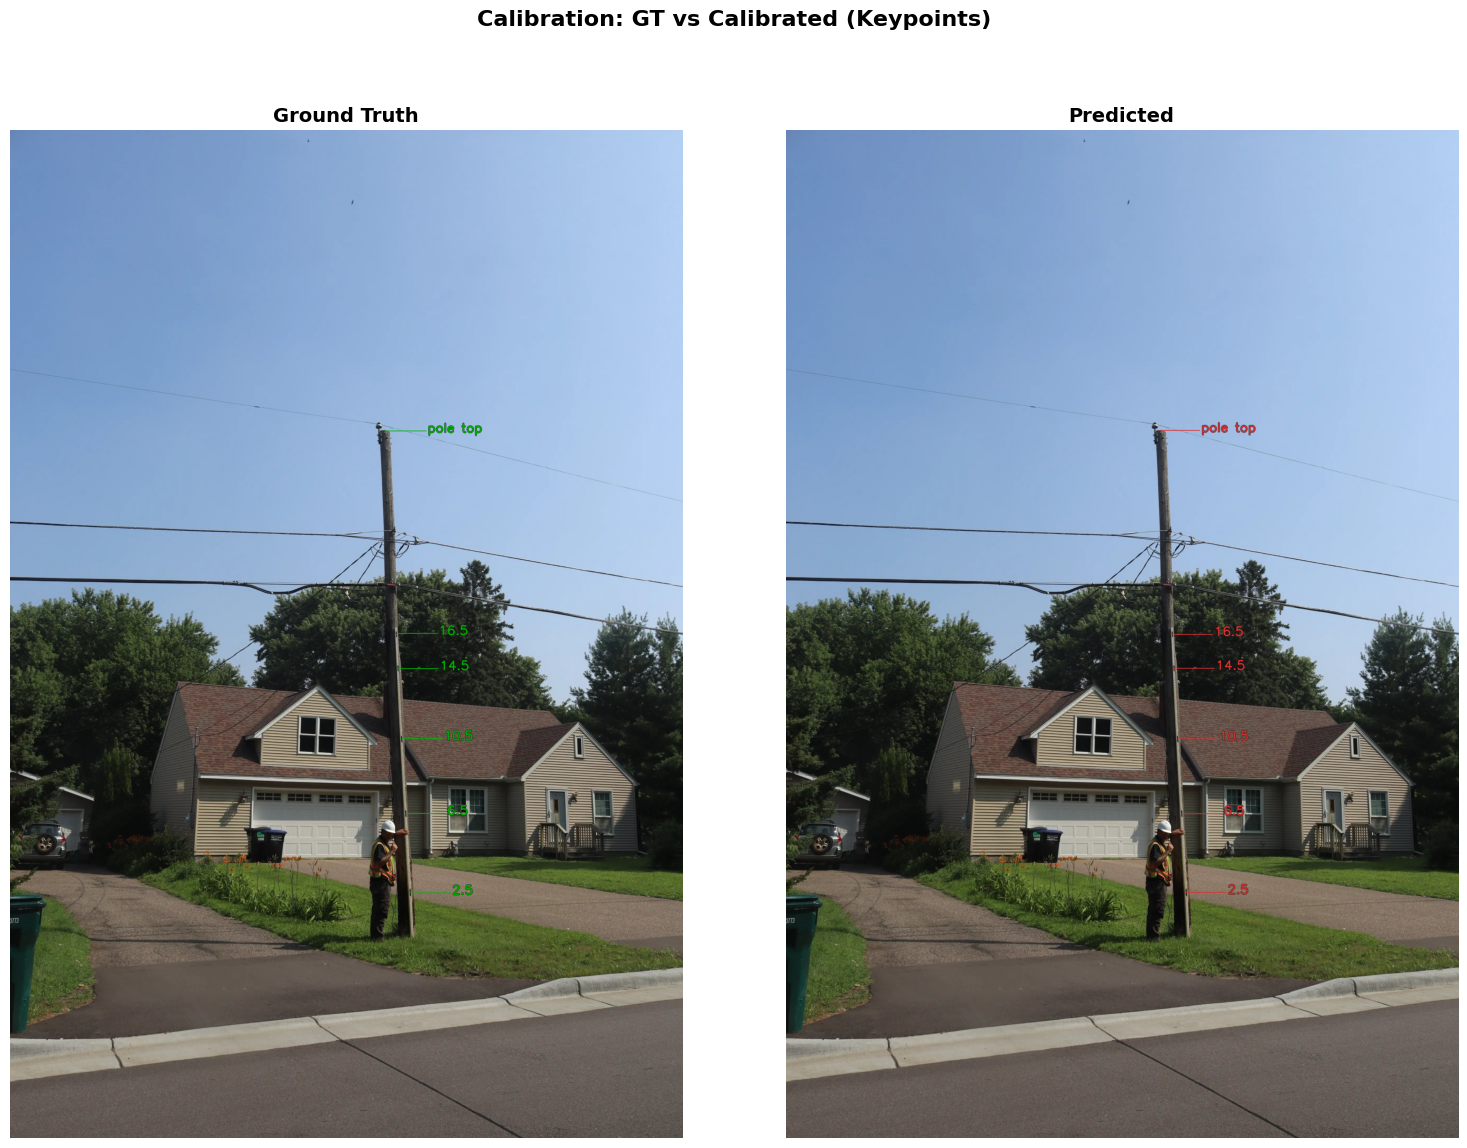

In [2]:
# Cell 1: Calibration Pipeline - GT vs Calibrated (keypoints only, no bbox)
models = load_all_models()
val_images = []
for ds in ["Pole detection", "Ruler detection"]:
    val_images.extend(sorted(VISUALIZATION_DATASETS_CONFIG[ds]['images_dir'].glob('*.jpg')))
random_image = random.choice(val_images)
in_pole_ds = (VISUALIZATION_DATASETS_CONFIG["Pole detection"]['images_dir'] / random_image.name).exists()
models_to_use = models if in_pole_ds else {**models, 'pole_detector': None, 'pole_top_model': None}

results = run_end_to_end_inference_simple(random_image, models_to_use, INFERENCE_USE_TTA, show_visualization=False)
img_rgb = cv2.cvtColor(cv2.imread(str(random_image)), cv2.COLOR_BGR2RGB)
gt_data = load_all_ground_truth(random_image, img_rgb, results)

# Keypoints only (no bboxes)
gt_viz = {'bboxes': [], 'keypoints': gt_data_to_viz_data(gt_data).get('keypoints', [])}
pred_viz = {'bboxes': [], 'keypoints': inference_results_to_viz_data(results).get('keypoints', [])}

# Inches error (PPI from pole top or ruler marking label)
from src.data_utils import load_ppi_from_label
from src.config import path_relative_to_project, POLE_LABELS_DIR
lbl_path = POLE_LABELS_DIR / f"{random_image.stem}_location.txt"
if not lbl_path.exists():
    lbl_path = Path(VISUALIZATION_DATASETS_CONFIG["Pole top"]['labels_dir']) / f"{random_image.stem}.txt"
ppi = load_ppi_from_label(lbl_path) if lbl_path.exists() else None
keypoint_errors_inch = []
if ppi and ppi > 0:
    gt_kps = gt_viz['keypoints']
    pred_kps = pred_viz['keypoints']
    for p in pred_kps:
        g = next((x for x in gt_kps if x['name'] == p['name']), None)
        if g:
            keypoint_errors_inch.append((p['name'], abs(p['y'] - g['y']) / ppi))

print_inference_summary(
    random_image,
    gt_bbox_count=2 if gt_data.get('gt_pole_bbox') or gt_data.get('gt_ruler_bbox') else 0,
    gt_keypoint_count=len(gt_viz['keypoints']),
    pred_bboxes=[{'label': 'pole', 'conf': None}, {'label': 'ruler', 'conf': None}] if results.get('pole') and results.get('ruler') else [],
    pred_keypoints=pred_viz['keypoints'],
    keypoint_errors_inch=keypoint_errors_inch,
)

line_length = (results.get('ruler') and (results['ruler'][2] - results['ruler'][0])) or max(10, img_rgb.shape[1] // 20)
show_gt_vs_pred(img_rgb, gt_viz, pred_viz, title='Calibration: GT vs Calibrated (Keypoints)', figsize=(16, 12), line_length=line_length, show_labels=True)

✓ Equipment detector loaded from models/production/equipment_detection/v1.0.4/model.pt
✓ Attachment detector loaded from models/production/attachment_detection/v1.0.3/model.pt
HRNet output channels: 256
✓ Riser keypoint detector loaded from models/production/riser_keypoint_detection/v1.0.3/model.pth
HRNet output channels: 256
✓ Transformer keypoint detector loaded from models/production/transformer_keypoint_detection/v1.0.3/model.pth
HRNet output channels: 256
✓ Street_Light keypoint detector loaded from models/production/street_light_keypoint_detection/v1.0.3/model.pth
HRNet output channels: 256
✓ Secondary_Drip_Loop keypoint detector loaded from models/production/secondary_drip_loop_keypoint_detection/v1.0.3/model.pth
HRNet output channels: 256
✓ comm keypoint detector loaded from models/production/comm_keypoint_detection/v1.0.3/model.pth
HRNet output channels: 256
✓ down_guy keypoint detector loaded from models/production/down_guy_keypoint_detection/v1.0.4/model.pth
HRNet output cha

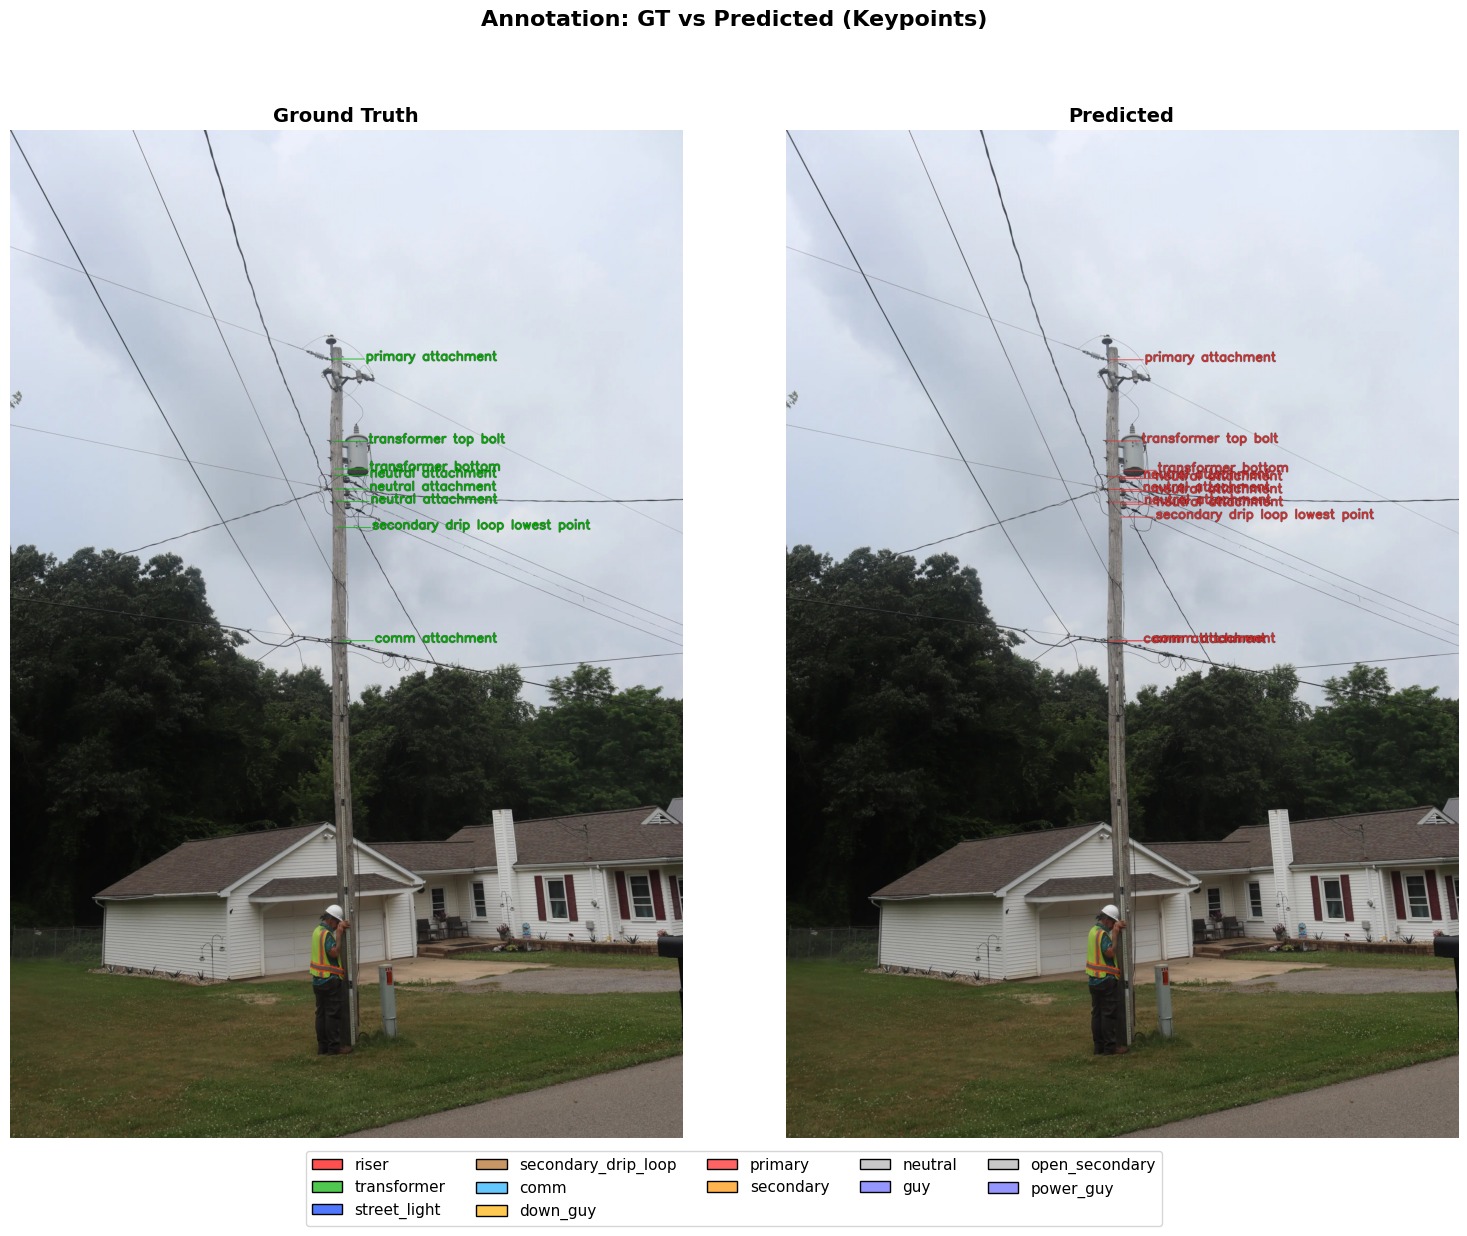

In [10]:
# Cell 2: Annotation Pipeline - GT vs Predicted (keypoints only, no bbox)
from src.inference import (
    load_pole_detector,
    load_equipment_detector,
    load_attachment_detector,
    load_keypoint_detector,
    load_attachment_keypoint_detector,
)
from src.evaluation_attachment_equipment import run_e2e_annotation_single_image
from src.data_utils import (
    parse_equipment_with_keypoints,
    parse_attachments_with_keypoints,
    get_e2e_val_images,
    load_ppi_from_label,
)
from src.config import POLE_LABELS_DIR, EQUIPMENT_KEYPOINT_CONFIGS, ATTACHMENT_KEYPOINT_CONFIGS, EQUIPMENT_COLORS, ATTACHMENT_COLORS

device = models['device']
pole_detector = models.get('pole_detector') or load_pole_detector(device)
equip_detector = load_equipment_detector(device)
attach_detector = load_attachment_detector(device)
# Load all equipment keypoint models (riser, transformer, street_light, secondary_drip_loop)
equip_kp = {}
for t in EQUIPMENT_KEYPOINT_CONFIGS:
    try:
        equip_kp[t] = load_keypoint_detector(t, device)
    except (FileNotFoundError, ValueError):
        print(f"  ⚠ Skipping {t} (weights not found)")
# Load all attachment keypoint models (comm, down_guy, primary, secondary, neutral, guy)
attach_kp = {}
for t in ATTACHMENT_KEYPOINT_CONFIGS:
    try:
        attach_kp[t] = load_attachment_keypoint_detector(t, device)
    except (FileNotFoundError, ValueError):
        print(f"  ⚠ Skipping {t} (weights not found)")

candidates = get_e2e_val_images('equipment')
with_loc = [p for p in candidates if (POLE_LABELS_DIR / f"{p.stem}_location.txt").exists()]
if not with_loc:
    raise RuntimeError("No manifest-test images with location labels found for GT comparison.")
random_img = random.choice(with_loc)

equip_preds, attach_preds, _ = run_e2e_annotation_single_image(
    random_img, pole_detector, equip_detector, attach_detector,
    equip_kp, attach_kp, device,
)

img_rgb = cv2.cvtColor(cv2.imread(str(random_img)), cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]
line_len = max(10, w // 20)

# GT keypoints from location file
gt_keypoints = []
lbl_path = POLE_LABELS_DIR / f"{random_img.stem}_location.txt"
eq_kp_map = {'riser': [('kp0', 'riser_top')], 'transformer': [('kp0', 'top_bolt'), ('kp1', 'bottom')],
             'street_light': [('kp0', 'upper_bracket'), ('kp1', 'lower_bracket'), ('kp2', 'drip_loop')],
             'secondary_drip_loop': [('kp0', 'lowest_point')]}
if lbl_path.exists():
    for eq in parse_equipment_with_keypoints(lbl_path):
        parent_name = eq.get('class_name', 'equipment')
        for kp_key, kp_name in eq_kp_map.get(parent_name, []):
            kp = eq.get(kp_key)
            if kp is not None:
                gt_keypoints.append({
                    'x': kp[0] / 100 * w,
                    'y': kp[1] / 100 * h,
                    'name': f"{parent_name} {kp_name}",
                })
    for att in parse_attachments_with_keypoints(lbl_path):
        if att.get('center'):
            parent_name = att.get('class_name', 'attachment')
            gt_keypoints.append({
                'x': att['center'][0] / 100 * w,
                'y': att['center'][1] / 100 * h,
                'name': f"{parent_name} attachment",
            })

# Pred keypoints
pred_keypoints = []
for det in equip_preds + attach_preds:
    parent_name = det.get('cls_name') or det.get('class_name') or 'object'
    for kp in det.get('keypoints', []):
        pred_keypoints.append({
            'x': kp['x'],
            'y': kp['y'],
            'name': f"{parent_name} {kp['name']}",
        })

gt_viz = {'bboxes': [], 'keypoints': gt_keypoints}
pred_viz = {'bboxes': [], 'keypoints': pred_keypoints}

# Inches error for keypoints (when PPI available)
ppi = load_ppi_from_label(lbl_path) if lbl_path.exists() else None
keypoint_errors_inch = []
if ppi and ppi > 0:
    for p in pred_keypoints:
        g = next((x for x in gt_keypoints if x['name'] == p['name']), None)
        if g:
            err_px = abs(p['y'] - g['y'])
            keypoint_errors_inch.append((p['name'], err_px / ppi))

# Pred bboxes for summary (from equip + attach)
pred_bboxes_viz = [{'label': d.get('cls_name', d.get('class_name', 'obj')), 'conf': d.get('conf')} for d in equip_preds + attach_preds]

print_inference_summary(
    random_img,
    gt_bbox_count=0,
    gt_keypoint_count=len(gt_keypoints),
    pred_bboxes=pred_bboxes_viz,
    pred_keypoints=pred_keypoints,
    keypoint_errors_inch=keypoint_errors_inch,
    compare_bboxes=False,
)

# Legend: all equipment + attachment classes
legend_items = {**EQUIPMENT_COLORS, **ATTACHMENT_COLORS}
show_gt_vs_pred(
    img_rgb,
    gt_viz,
    pred_viz,
    title='Annotation: GT vs Predicted (Keypoints)',
    figsize=(16, 12),
    line_length=line_len,
    show_labels=True,
    legend_items=legend_items,
)
